<a href="https://colab.research.google.com/github/carlosedcec/fake-news-predictor/blob/master/Modelo_de_Predi%C3%A7%C3%A3o_de_Fake_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Predictor
- A ideia deste modelo é ser um preditor de notícias podendo classificar uma notícia como verdadeira ou falsa. <br>
- Foram utilizados 2 diferentes datasets para construir o dataset de treino e teste do modelo.
  - https://www.kaggle.com/datasets/aadyasingh55/fake-news-classification
  - https://www.kaggle.com/datasets/mahdimashayekhi/fake-news-detection-dataset
- Os datasets utilizados são de língua inglesa, portanto, o modelo funciona analisando notícias em inglês.
- Os textos das notícias são pré-processados de acordo com algoritmo de exemplo fornecido no github da disciplina.
- Foi utilizado o TfidfVectorizer para vetorizar os textos.
- Neste notebook são testados 4 diferentes algoritmos de machine learning: KNN, Naive Bayes, Random Forest e Logistic Regression.
- O algoritmo que apresentou melhor desempenho foi o Logistic Regression, com uma acurácia de 97%.
- Ao final, o modelo é treinado com todo o dataset e então testado em novo dataset completamente diferente. Este dataset foi criado por mim através de pesquisas na internet e ajuda de inteligência artificial e contêm 100 notícias que variam entre verdadeiras e falsas. O modelo apresentou uma taxa de acerto de 77%.

## 1) Configuração do ambiente
Imports das bibliotecas e funções que serão utilizadas no notebook.

In [ ]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports gerais
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pickle import dump

# Imports do scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

# Bibliotecas para manipulação de texto e NLP
import nltk
from tqdm.auto import tqdm
from nltk.corpus import stopwords

# Bloco de configuração inicial do NLTK
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## 2) Carregamento dos dados
Carregaento dos dados a partir dos links do csvs que estão no repositório github do mvp.

In [ ]:
# Função que configura e padroniza os diferentes csvs, retornando um data frame
def create_data_frame_from_files(datasets):

    # Leitura e concatenação dos data frames
    dfs = []
    for url in datasets:
        print(f"Loading {url}")
        d = pd.read_csv(url, sep=None, engine="python", encoding="utf-8")
        d.columns = d.columns.str.strip().str.lower()
        dfs.append(d)
    df = pd.concat(dfs, ignore_index=True)

    # Normaliza as colunas do dataframe
    for col in ["title", "text", "label"]:
        if col not in df.columns:
            df[col] = np.nan if col != "text" else ""

    # Confiura o título e a label
    df["combined_text"] = df["title"].fillna("") + " " + df["text"].fillna("")
    df["label"] = (df["label"].astype(str).map({ "real": 1, "fake": 0, "1": 1, "0": 0 }))

    # Finaliza o data frame e dropa colunas nulas
    df = df[["combined_text", "label"]]
    df = df.dropna(subset=["combined_text", "label"])

    return df

# Links dos datasets
datasets = [
    'https://raw.githubusercontent.com/carlosedcec/fake-news-predictor/refs/heads/master/api/ml/data/aadyasingh55-fake-news-classification/evaluation.csv',
    'https://raw.githubusercontent.com/carlosedcec/fake-news-predictor/refs/heads/master/api/ml/data/aadyasingh55-fake-news-classification/test%20(1).csv',
    'https://raw.githubusercontent.com/carlosedcec/fake-news-predictor/refs/heads/master/api/ml/data/aadyasingh55-fake-news-classification/train%20(2).csv'
]

print("Loading data...")
df = create_data_frame_from_files(datasets)
print("Data loaded!\n")

# Mostra as primeiras linhas do dataframe
df.head(10)

Loading data...
Loading https://raw.githubusercontent.com/carlosedcec/fake-news-predictor/refs/heads/master/api/ml/data/aadyasingh55-fake-news-classification/evaluation.csv
Loading https://raw.githubusercontent.com/carlosedcec/fake-news-predictor/refs/heads/master/api/ml/data/aadyasingh55-fake-news-classification/test%20(1).csv
Loading https://raw.githubusercontent.com/carlosedcec/fake-news-predictor/refs/heads/master/api/ml/data/aadyasingh55-fake-news-classification/train%20(2).csv
Data loaded!



,combined_text,label
0,"Sanders back in U.S. Senate, blasts 'coloniali...",1
1,Kremlin: Syria peoples' congress being 'active...,1
2,Oregon Cop Convicted Of Shattering Biker’s Co...,0
3,Twitter Erupts With Glee Over #CruzSexScandal...,0
4,MUST WATCH VIDEO: Obama Tries To Trash Trump B...,0
5,AL Cops Kill Suicidal Woman After Her Parents...,0
6,U.S. judge to mull release of Trump video test...,1
7,Chinese State Media Calls Trump Out After He ...,0
8,"Texas Moving To Ban Jews, Muslims, and Gays f...",0
9,House Dem Drops SHOCKING Bombshell On Nationa...,0


## 3) Processamento dos dados
Pré-processa os textos, limpando e tokenizando eles de acordo com o algoritmo que foi disponibilizado no notebook de classificação de texto através do github da disciplina.

In [ ]:
# Função para pré-processar o texto
def preprocess_text(row) -> str:
    """
    Função completa para limpar e pré-processar um único documento de texto.
    Aplica todos os passos da proposta: remoção de metadados, lowering,
    remoção de pontuação/números, tokenização e remoção de stopwords.
    """

    text = row["combined_text"]

    def sanitize_text(text):
        text = re.sub(r"--.*", "", text, flags=re.DOTALL) # Remove assinaturas (começando com '-- ')
        text = re.sub(r">.*", "", text) # Remove linhas de citação (começando com '>')
        text = re.sub(r"\S*@\S*\s?", "", text) # Remove emails
        text = re.sub(r"\s+", " ", text).strip() # Remove quebras de linha e tabs
        text = text.lower()
        return text

    text = sanitize_text(text)

    tokens = text.split()

    stop_words = set(stopwords.words("english"))

    clean_tokens = [
        token
        for token in tokens
        if token not in stop_words
        and len(token) > 2  # Remove stopwords e tokens muito curtos
    ]

    return " ".join(clean_tokens)

tqdm.pandas(desc="Preprocessing")

print("Preprocessing text...")
X = df.progress_apply(preprocess_text, axis=1)
print("Text preprocessed!\n")
y = np.array(df["label"].values, dtype=int)

Preprocessing text...


Preprocessing:   0%|          | 0/40587 [00:00<?, ?it/s]

Text preprocessed!



## 4) Separação em conjunto de treino e conjunto de teste
Separa os dados entre conjunto de treino e conjunto de teste com estratificação.

In [ ]:
# Seta variáveis de configuração
SEED = 7
TEST_SIZE = 0.20
SCORING = 'f1_macro'
NUM_PARTICOES = 5

# Separa dados em treino e teste com estratificação
print("Splitting data into train and test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=True, random_state=SEED, stratify=y
)
print("Data splitted!\n")

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples\n")

Splitting data into train and test...
Data splitted!

Training set: 32469 samples
Test set: 8118 samples



## 5) Avaliação dos modelos - linha base
Cria tuplas para os algoritmos, para o tfidf vecttorizer e para o kfold que sera utilizado para validação cruzada; então cria uma pipeline para cada algoritmo e testa para verificar os resultados de cada uma.

In [ ]:
# Algoritmos que serão utilizados
knn = ('KNN', KNeighborsClassifier())
random_forest = ('RF', RandomForestClassifier(random_state=SEED))
naive_bayes = ('NB', MultinomialNB())
logistic_regression = ('LogisticREG', LogisticRegression(max_iter=1000))

# TfidfVetorizer para pipeline
tfidf = ('tfidf', TfidfVectorizer(min_df=2, max_df=0.9))

# Kfold com estratificação
kfold = StratifiedKFold(n_splits=NUM_PARTICOES, shuffle=True, random_state=SEED)

Avaliating algorithms...
KNN: 0.848 (0.007)
RF: 0.976 (0.001)
NB: 0.926 (0.003)
LogisticREG: 0.972 (0.001)


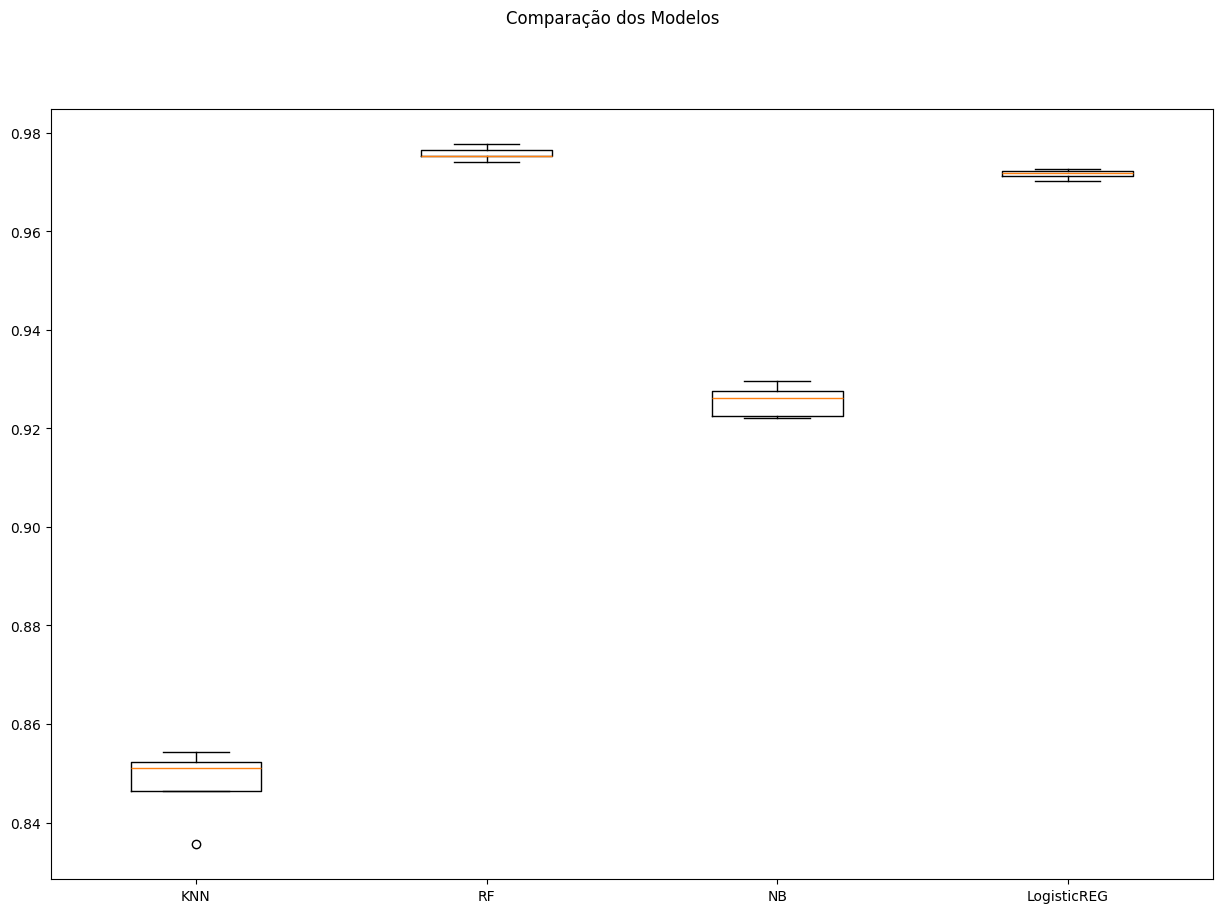

In [ ]:
# Lista que armazenará os modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos com pipelines que primeiro vetorizam o texto através do Tfidf
models.append(('KNN', Pipeline([tfidf, knn])))
models.append(('RF', Pipeline([tfidf, random_forest])))
models.append(('NB', Pipeline([tfidf, naive_bayes])))
models.append(('LogisticREG', Pipeline([tfidf, logistic_regression])))

# Listas para armazenar os resultados
names = []
results = []

print("Avaliating algorithms...")

# Avaliação dos modelos
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=SCORING)
    names.append(name)
    results.append(cv_results)
    print("%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()))

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()


## 6) Avaliação dos modelos - dados padronizados e normalizados
Cria scalers para testar os dados com padronização e normalização; então cria três pipelines para cada algoritmo - uma com os dados originais, outra com os dados padronizados e outra com os dados normalizados e testa para verificar os resultados de cada uma.

In [ ]:
# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler(with_mean=False))
min_max_scaler = ('MinMaxScaler', MaxAbsScaler())


Avaliating algorithms with scaled data...
KNN-orig: 0.848 (0.007)
RF-orig: 0.976 (0.001)
NB-orig: 0.926 (0.003)
LogisticREG-orig: 0.972 (0.001)
KNN-padr: 0.376 (0.006)
RF-padr: 0.976 (0.001)
NB-padr: 0.906 (0.003)
LogisticREG-padr: 0.963 (0.003)
KNN-norm: 0.382 (0.010)
RF-norm: 0.976 (0.001)
NB-norm: 0.937 (0.003)
LogisticREG-norm: 0.981 (0.002)


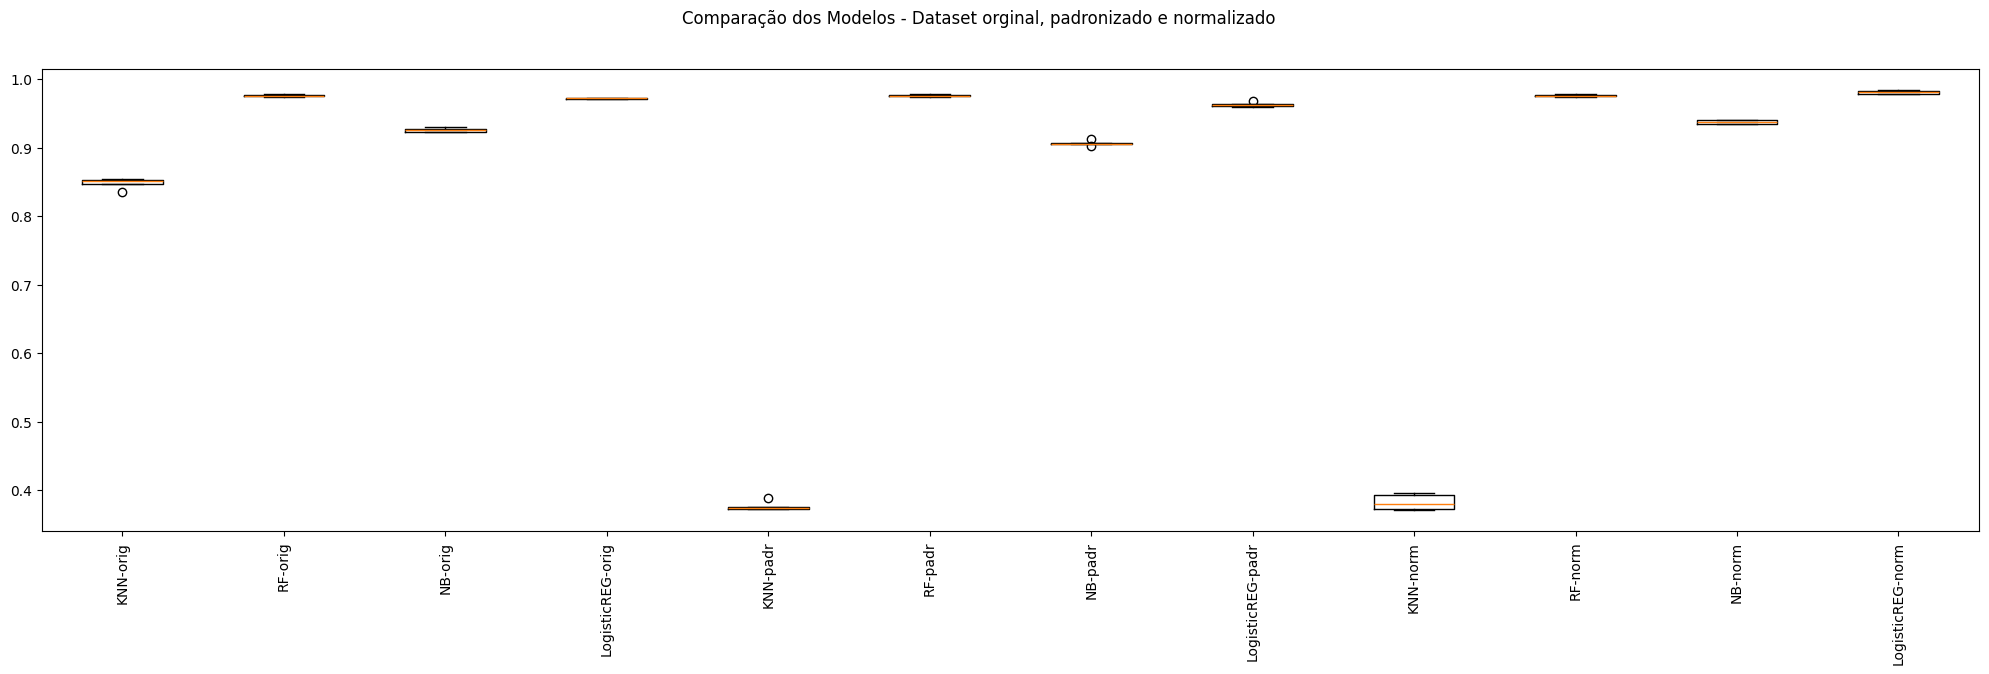

In [ ]:
# Listas para armazenar os resultados
names = []
results = []

# Lista que armazenará as pipelines
pipelines = []

# Dataset original
pipelines.append(('KNN-orig', Pipeline([tfidf, knn])))
pipelines.append(('RF-orig', Pipeline([tfidf, random_forest])))
pipelines.append(('NB-orig', Pipeline([tfidf, naive_bayes])))
pipelines.append(('LogisticREG-orig', Pipeline([tfidf, logistic_regression])))

# Dataset padronizado
pipelines.append(('KNN-padr', Pipeline([tfidf, standard_scaler, knn])))
pipelines.append(('RF-padr', Pipeline([tfidf, standard_scaler, random_forest])))
pipelines.append(('NB-padr', Pipeline([tfidf, standard_scaler, naive_bayes])))
pipelines.append(('LogisticREG-padr', Pipeline([tfidf, standard_scaler, logistic_regression])))

# Dataset normalizado
pipelines.append(('KNN-norm', Pipeline([tfidf, min_max_scaler, knn])))
pipelines.append(('RF-norm', Pipeline([tfidf, min_max_scaler, random_forest])))
pipelines.append(('NB-norm', Pipeline([tfidf, min_max_scaler, naive_bayes])))
pipelines.append(('LogisticREG-norm', Pipeline([tfidf, min_max_scaler, logistic_regression])))

# Listas para armazenar os resultados
names = []
results = []

print("\nAvaliating algorithms with scaled data...")

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=SCORING)
    names.append(name)
    results.append(cv_results)
    print("%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()))

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

## 7) Otimização de hiperparâmetros
Testa diferentes hiperparâmetros para os algoritmos que se saíram melhore nos testes anteriores através do GridSearchCV.

In [ ]:
print("\nOptimizing hiperparameters...")

# Testando otimização de hiperparâmetros da Random Forest
random_forest_pipelines = []
random_forest_pipelines.append(('rf-orig', Pipeline([tfidf, random_forest])))
random_forest_pipelines.append(('rf-padr', Pipeline([tfidf, standard_scaler, random_forest])))
random_forest_pipelines.append(('rf-norm', Pipeline([tfidf, min_max_scaler, random_forest])))

param_grid = [
    {
        'RF__n_estimators': [100, 200],
        'RF__max_depth': [None, 10, 30],
        'RF__min_samples_split': [2, 5],
        'RF__min_samples_leaf': [1, 2]
    }
]

for name, model in random_forest_pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=SCORING, cv=kfold)
    grid.fit(X_train, y_train)
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

# Testando otimização de hiperparâmetros da Logistic Regression
logistic_reg_pipelines = []
logistic_reg_pipelines.append(('logistic_reg-orig', Pipeline([tfidf, logistic_regression])))
logistic_reg_pipelines.append(('logistic_reg-padr', Pipeline([tfidf, standard_scaler, logistic_regression])))
logistic_reg_pipelines.append(('logistic_reg-norm', Pipeline([tfidf, min_max_scaler, logistic_regression])))

param_grid = [
    {
        'LogisticREG__l1_ratio': [0],
        'LogisticREG__solver': ['lbfgs', 'liblinear', 'saga'],
        'LogisticREG__C': [0.1, 1, 10],
        'LogisticREG__tol': [1e-4, 1e-3]
    },
    {
        'LogisticREG__l1_ratio': [1],
        'LogisticREG__solver': ['liblinear', 'saga'],
        'LogisticREG__C': [0.1, 1, 10],
        'LogisticREG__tol': [1e-4, 1e-3]
    }
]

for name, model in logistic_reg_pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=SCORING, cv=kfold)
    grid.fit(X_train, y_train)
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))


Optimizing hiperparameters...
Sem tratamento de missings: rf-orig - Melhor: 0.977179 usando {'RF__max_depth': None, 'RF__min_samples_leaf': 1, 'RF__min_samples_split': 2, 'RF__n_estimators': 200}
Sem tratamento de missings: rf-padr - Melhor: 0.977148 usando {'RF__max_depth': None, 'RF__min_samples_leaf': 1, 'RF__min_samples_split': 2, 'RF__n_estimators': 200}
Sem tratamento de missings: rf-norm - Melhor: 0.976931 usando {'RF__max_depth': None, 'RF__min_samples_leaf': 1, 'RF__min_samples_split': 2, 'RF__n_estimators': 200}
Sem tratamento de missings: logistic_reg-orig - Melhor: 0.982212 usando {'LogisticREG__C': 10, 'LogisticREG__l1_ratio': 1, 'LogisticREG__solver': 'saga', 'LogisticREG__tol': 0.0001}
Sem tratamento de missings: logistic_reg-padr - Melhor: 0.981685 usando {'LogisticREG__C': 0.1, 'LogisticREG__l1_ratio': 1, 'LogisticREG__solver': 'liblinear', 'LogisticREG__tol': 0.001}
Sem tratamento de missings: logistic_reg-norm - Melhor: 0.982894 usando {'LogisticREG__C': 10, 'Logist

## 8) Preperação do modelo
Prepara um modelo com o algoritmo de melhor resultado e com os respectivos hiperparâmetros que obtiveram os melhores resultados e então testa ele com os dados de teste para verificar sua eficácia.

OBS: Apesar dos resultados obtidos no teste de hiperparâmetros, foi verificado que o modelo se comporta muito melhor para a predição de dados completamente diferentes daqueles existentes nos conjuntos de treino utilizando os parâmetros *defaults* da LogisticRegression. Portanto, para melhores resultados de generalização de dados, optou-se por utilizar tais parâmetros *defaults* ao invés dos indicados pelo GridSearchCV (levando em conta, sobretudo, que a diferença de desempenho entre os parâmetros *defaults* e os melhores parâmetros indicados pelo GridSearchCV foram de 0,1%).


Preparing model...

Accuracy: 0.975

Classification report:
              precision    recall  f1-score   support

           0      0.972     0.973     0.973      3733
           1      0.977     0.976     0.977      4385

    accuracy                          0.975      8118
   macro avg      0.975     0.975     0.975      8118
weighted avg      0.975     0.975     0.975      8118


Confusion matrix:


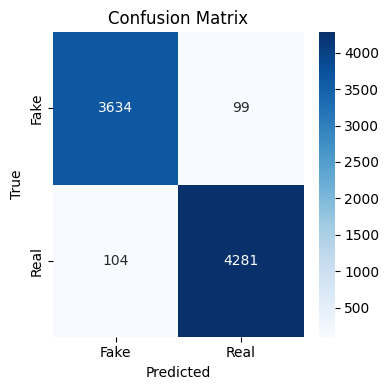

In [ ]:
print("\nPreparing model...")

# Preparando o modelo
logistic_regression = ('LogisticREG', LogisticRegression(max_iter=1000))
model = Pipeline([tfidf, logistic_regression])
model.fit(X_train, y_train)

# Estimativa da acurácia no conjunto de teste
predictions = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, predictions):.3f}")

# Relatório de métricas
print("\nClassification report:")
print(classification_report(y_test, predictions, digits=3))

# Matriz de confusão
print("\nConfusion matrix:")
cm = confusion_matrix(y_test, predictions)
class_names = ["Fake", "Real"]
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 9) Finalização do modelo
Finaliza o modelo com todos os dados do dataset.

In [ ]:
print("\nFinalizing model...")
model = Pipeline([tfidf, logistic_regression])
model.fit(X, y) # Preparação do modelo com TODO o dataset
print("Model finalized!")


Finalizing model...
Model finalized!


## 10) Exportação do modelo
Faz o dump do modelo para um arquivo pickle.

In [ ]:
print("\nDumping model pipeline...")
model_name = input("Please enter model file name: ")
dump(model, open(f"{model_name}.pkl", 'wb'))
print("Model pipeline dumped!")


Dumping model...
Please enter model file name: fake_news_classification_pipeline_lr
Model Dumped!


## 11) Testando novos dados
Carrega um dataset de dados completamente diferentes e testa o modelo com esses novos dados para verificar sua eficácia em um cenário desconhecido.

In [ ]:
print("\nTesting new data...")

# Carrega csv com dados inteiramente novos
df = pd.read_csv('https://raw.githubusercontent.com/carlosedcec/fake-news-predictor/refs/heads/master/api/ml/data/testdata/test_data.csv', sep=';', encoding='utf-8-sig')

# Configura o csv
df["combined_text"] = df["title"].fillna("") + " " + df["text"].fillna("")

# Pré-processa os textos setando os valores X
X_entrada = df.progress_apply(preprocess_text, axis=1)

# Faz a predição dos dados
saidas = model.predict(X_entrada)

# Seta os valores de Y com as saídas esperadas
Y_saidas_esperadas = np.array(df["label"].values, dtype=int)

# Calcula a taxa de acerto
counter = 0
for idx, label in enumerate(Y_saidas_esperadas):
    if label == saidas[idx]:
        counter = counter + 1
result_rate = (counter*100) / len(df["label"].values)

print(f"Test results: {result_rate:.2f}% of correct answers")


Testing new data...


Preprocessing:   0%|          | 0/100 [00:00<?, ?it/s]

Test results: 77.00% of correct answers


# Conclusões

Ao me deparar com um dataset de fake news achei interessante e desafiante a ideia de tentar construir um modelo de machine learning capaz de predizer se uma notícia seria verdadeira ou falsa; comecei, então, a pesquisar mais dados.

Meu primeiro intuito foi o de tentar obter o maior número de datasets possíveis, em diferentes línguas possíveis, pois tinha a ideia de criar um modelo multi-idiomas. Coletei 5 datasets diferentes em 3 línguas diferentes totalizando mais de 120 mil dados rotulados. O treinamento do modelo até que estava funcionando, mas eu não conseguia uma acurácia de mais de 80% e, ao testar meu modelo com um conjunto de dados completamente diferentes, a taxa de acertos ficava entre 70 e 65%, sendo que, quanto mais dados eu colocava nesse novo conjunto para teste, menor era a taxa de acertos, dando a impressão do modelo ser mais um bom chutador do que um preditor de fato.

Através das aulas, entendi que não era uma boa escolha misturar diferentes idiomas para um modelo de machine learning pois os pesos das palavras em um idioma poderiam interferir no peso das palavras em outro, dificultando o entendimento do modelo sobre o texto. Sendo assim, fiquei apenas com os dois datasets que eu tinha em língua inglesa, pois eles eram aqueles que tinham o maior número de dados. O modelo respondeu e obtive uma melhora em seus resultados, porém, ele ainda não parecia estar muito estável.

Decidi então testar cada um desses dois dataset por vez e vi que, enquanto um deles, sozinho, me dava uma acurácia de 97% no teste, o outro, sozinho, me dava uma acurácia de 50%. Me pareceu, então, que esse segundo dataset estava populado com dados de má qualidade, ou que não serviam para o propóstio que eu queria. Sendo assim, acabei ficando somente com o primeiro dataset e, a partir dele, obtive os melhores resultados de até então (tanto para o treino/teste do meu modelo, quanto para dados completamente diferentes do meu dataset de treino/teste).

Também pude observar que o modelo que melhor generalizava e obtinha uma maior taxa de acertos para dados completamente diferentes não era necessariamente o modelo que se saia melhor no treino/teste com o dataset de treino/teste. Apesar de o algoritmo de Random Forest e de Logistic Regression apresentarem taxas de acerto muito similares no meu treino/teste, quando utilizados para generalizar com dados completamente diferentes, o Logistic Regression se saia consideravelmente melhor. O mesmo foi observado com relação aos hiperparâmetros do GridSearchCV: os parâmetros *default* do LogisticRegression se saíram melhor na generalização do que os parâmetros apontados pelos testes do grid.

Por fim, também notei que o modelo, depois de pronto, parece se sair muito melhor predizendo notícias relacionadas à política/economia/mundo/atualidades, do que outros tópicos como esportes/entretenimento/celebridades/ciências/saúde, o que, provavelmente, está relacionado com o tipo de notícias que estão presentes no dataset de treino, fazendo com que o modelo se saia bem para notícias dos mesmos assuntos que o dele, mas não tão bem para notícias de outros assuntos.

Portanto, se fosse para tentar pontuar o que observei de mais importante no processo foi:
- Para modelos de machine learning mais clássicos que lidam com texto não é aconselhável misturar diferentes idiomas;
- Mais dados não necessariamente significam melhores resultados, pode ser preferível menos dados de maior qualidade do que mais dados de menor qualidade;
- Ao tentar misturar diferentes datasets pode ser importante testar eles separadamente para ver como o modelo se comporta com cada um individualmente e se eles servem para o propósito desejado;
- É importante testar o modelo final com dados completamente diferentes para averiguar a capacidade de generalização do modelo;
- Não necessariamente os melhores hiperparâmetros analisados pelo GridSearch são aqueles que se sairão melhor num cenário de generalização com dados completamente diferentes daqueles do dataset de treino;
- Para construir um modelo que aborda diferentes dados que podem variar de "tipo", "estilo" ou "natureza" (como o caso dos diferentes assuntos de notícias), é necessário ter datasets que abranjam estes diferentes dados para que ele generalize bem e tenha um bom desempenho.